# b(t) Estimation and Comparison

This notebook compares three b-value curves: Bayesian event-by-event, fixed time-window MLE, and model prediction.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
from scipy.ndimage import gaussian_filter1d

from config.config_loader import load_args_from_yaml
from src.data.bayesian_b_updater import BayesianGRBUpdater
from src.data.preparation import prepare_data_tpp
from src.data.slidewindow_b_updater import FixedTimeWindowGRB
from src.train.config_setup import load_and_prepare_model
from src.utils.utils import _to_np_datetime64_seconds, set_xaxis_time_locator

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


## Load Checkpoint and Dataset

In [2]:
checkpoint_dir = Path("../checkpoints/mixer_tpp_20260207-095619")
checkpoint_path = checkpoint_dir / "best_model_1.pth"

args = load_args_from_yaml(checkpoint_dir / "config.yaml")
args.use_b_updater = False

base_dir = f"../data/{args.dataset}"
seq, train_loader, val_loader, test_loader, catalog_ds = prepare_data_tpp(
    base_dir=base_dir,
    args=args,
)

ts_start = catalog_ds.metadata["start_ts"]
mc = catalog_ds.metadata["mag_completeness"]


Loading existing catalog from /root/autodl-tmp/chuandian_eq/data/ChuanDian/raw.
Number of training events: 4498
Number of validation events: 567


## Estimate b(t) with Bayesian and Fixed-Window Methods

In [3]:
bayes_updater = BayesianGRBUpdater(
    Mc=mc,
    delta=0.98,
    a0=50,
    init_b_target=1,
    mag_key="mag",
    write_back=True,
)
_ = bayes_updater.fit(seq, prefix="bayes_")

fixed_window_est = FixedTimeWindowGRB(
    Mc=mc,
    window_len=180.0,
    min_count=50,
    mag_key="mag",
    time_key="arrival_times",
    method="mle",
)
fixed_window_est.fit(seq, prefix="fixed_")


{'fixed_b_mean': tensor([   nan,    nan,    nan,  ..., 0.7852, 0.7852, 0.7874]),
 'fixed_n_used': tensor([  1,   2,   3,  ..., 160, 160, 161]),
 'fixed_win_len': tensor([180., 180., 180.,  ..., 180., 180., 180.]),
 'fixed_used_mask': tensor([1, 1, 1,  ..., 1, 1, 1])}

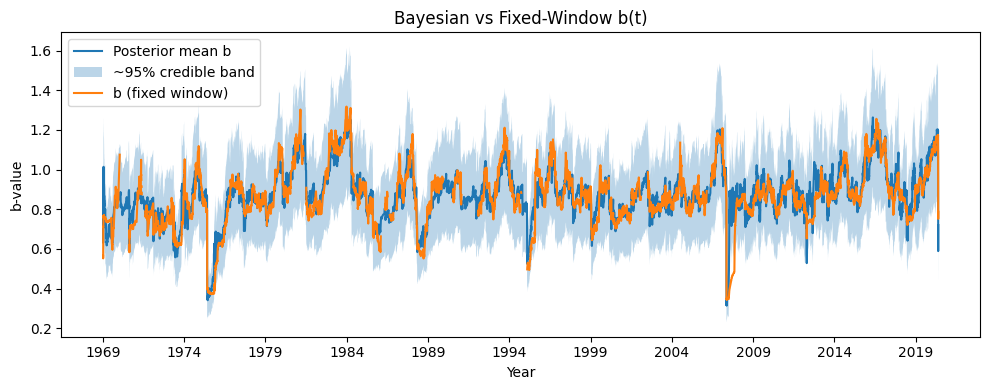

In [4]:
fig, ax = plt.subplots(figsize=(10, 4))

BayesianGRBUpdater.plot(
    seq,
    x_axis="time",
    time_key="arrival_times",
    prefix="bayes_",
    ax=ax,
    title="",
    show=False,
    start_time=ts_start,
)
FixedTimeWindowGRB.plot(
    seq,
    x_axis="time",
    prefix="fixed_",
    show_counts=False,
    ax=ax,
    title="",
    show=False,
    start_time=ts_start,
)

ax.set_title("Bayesian vs Fixed-Window b(t)")
ax.legend(loc="best")
plt.tight_layout()
plt.show()


## Predict b(t) from the Trained Model

In [5]:
model, model_args = load_and_prepare_model(checkpoint_path, device=device)

def plot_b_value(
    seq,
    b_seq: torch.Tensor,
    x_axis: str = "time",
    time_key: str = "arrival_times",
    title: str = "",
    label: str = "b-value",
    fig: plt.Figure = None,
    ax: plt.Axes = None,
    show: bool = True,
    smooth: bool = False,
    smooth_sigma: float = 1.0,
    start_time: pd.Timestamp = None,
):
    if isinstance(b_seq, torch.Tensor):
        b_seq = b_seq.squeeze().detach().cpu().numpy()

    if smooth:
        b_seq = gaussian_filter1d(b_seq, sigma=smooth_sigma)

    if x_axis == "time":
        if time_key not in seq:
            raise KeyError(f"Sequence is missing the time field '{time_key}'")
        days = seq[time_key].detach().cpu().numpy().squeeze()
        if len(days) != len(b_seq):
            days = days[: len(b_seq)]

        if start_time is None:
            xs = days
            xlabel = "Time (days)"
        else:
            t0_np = _to_np_datetime64_seconds(start_time)
            xs = t0_np + days.astype("timedelta64[D]")
            xlabel = "Year"
    elif x_axis == "event":
        xs = range(len(b_seq))
        xlabel = "Event index"
    else:
        raise ValueError("x_axis must be 'time' or 'event'")

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 4))

    ax.plot(xs, b_seq, label=label)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("b-value")
    ax.set_title(title)
    ax.legend(loc="best")
    ax.grid(alpha=0.3)

    if x_axis == "time" and start_time is not None:
        set_xaxis_time_locator(ax, start_time)

    plt.tight_layout()
    if show:
        plt.show()
    return fig, ax


MixerTPP context size: 64
load_specific_parts: None
Checkpoint loaded: <All keys matched successfully>
hyperparameters: {'resume_path': './checkpoints/mixer_tpp_20260203-161948/last_model_1.pth', 'load_specific_parts': ['encoder'], 'model': 'mixer_tpp', 'num_event_types': 1, 'pad_token_id': 1, 'task_type': 'tpp', 'batch_size': 1, 'accumulation_steps': 1, 'warmup_ratio': 0.1, 'learning_rate': 0.001, 'weight_decay': 0.01, 'scheduler_factor': None, 'scheduler_patience': None, 'scheduler_threshold': None, 'scheduler_min_lr': 1e-06, 'scheduler_type': 'step_warmup', 'step_lr_step_size_ratio': 0.2, 'step_lr_gamma': 0.8, 'dropout': 0.3, 'd_model': 64, 'mixer_model_config': {'input_dim': 1, 'dropout_prob': 0.1, 'd_model': 64, 'n_layer': 3, 'd_intermediate': 128, 'attn_layer_idx': [1], 'input_proj_type': 'mlp', 'input_proj_hidden': 128, 'input_proj_activation': 'silu', 'input_proj_dropout': 0.1, 'input_init': 'kaiming_uniform', 'input_init_scale': 1.5, 'ssm_cfg': {'layer': 'Mamba2Rotary', 'use_c

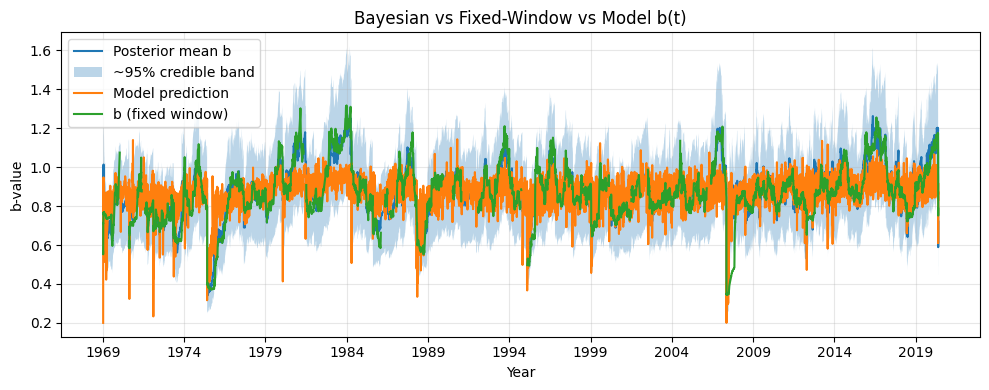

In [6]:
b_pred = model.compute_b_value(seq.to(device), True)[:, :-1]

fig, ax = plt.subplots(figsize=(10, 4))
BayesianGRBUpdater.plot(
    seq,
    x_axis="time",
    time_key="arrival_times",
    prefix="bayes_",
    ax=ax,
    title="",
    show=False,
    start_time=ts_start,
)
plot_b_value(
    seq,
    b_pred,
    label="Model prediction",
    smooth=False,
    fig=fig,
    ax=ax,
    show=False,
    start_time=ts_start,
)
FixedTimeWindowGRB.plot(
    seq,
    x_axis="time",
    prefix="fixed_",
    show_counts=False,
    ax=ax,
    title="",
    show=False,
    start_time=ts_start,
)

ax.set_title("Bayesian vs Fixed-Window vs Model b(t)")
ax.legend(loc="best")
plt.tight_layout()
plt.savefig(checkpoint_dir / "b_result.pdf", bbox_inches="tight")
plt.show()
